In [4]:
%pip install xgboost lightgbm catboost scikit-learn pandas numpy matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.


✅ All libraries imported!
Train : (630000, 21)  |  Test : (270000, 20)
   id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0   0     Loamy     4.92          32.58            1.01   
1   1      Clay     7.08          56.61            0.44   
2   2      Clay     5.69          27.71            0.81   
3   3     Sandy     5.65          13.32            1.33   
4   4      Clay     7.96          59.14            0.38   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                     3.05          15.01     50.61       725.99   
1                     2.00          22.92     67.86       985.66   
2                     2.83          26.97     92.22      2201.70   
3                     0.87          13.32     61.57      1357.33   
4                     0.96          20.22     91.11      1538.20   

   Sunlight_Hours  ...  Crop_Type Crop_Growth_Stage  Season Irrigation_Type  \
0            5.90  ...  Sugarcane            Sowing    Zaid            Drip   
1      

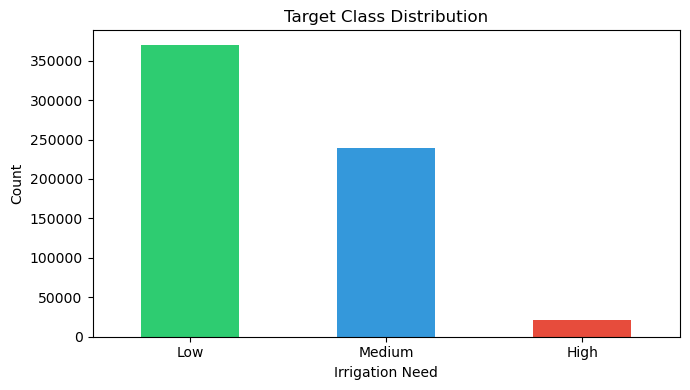

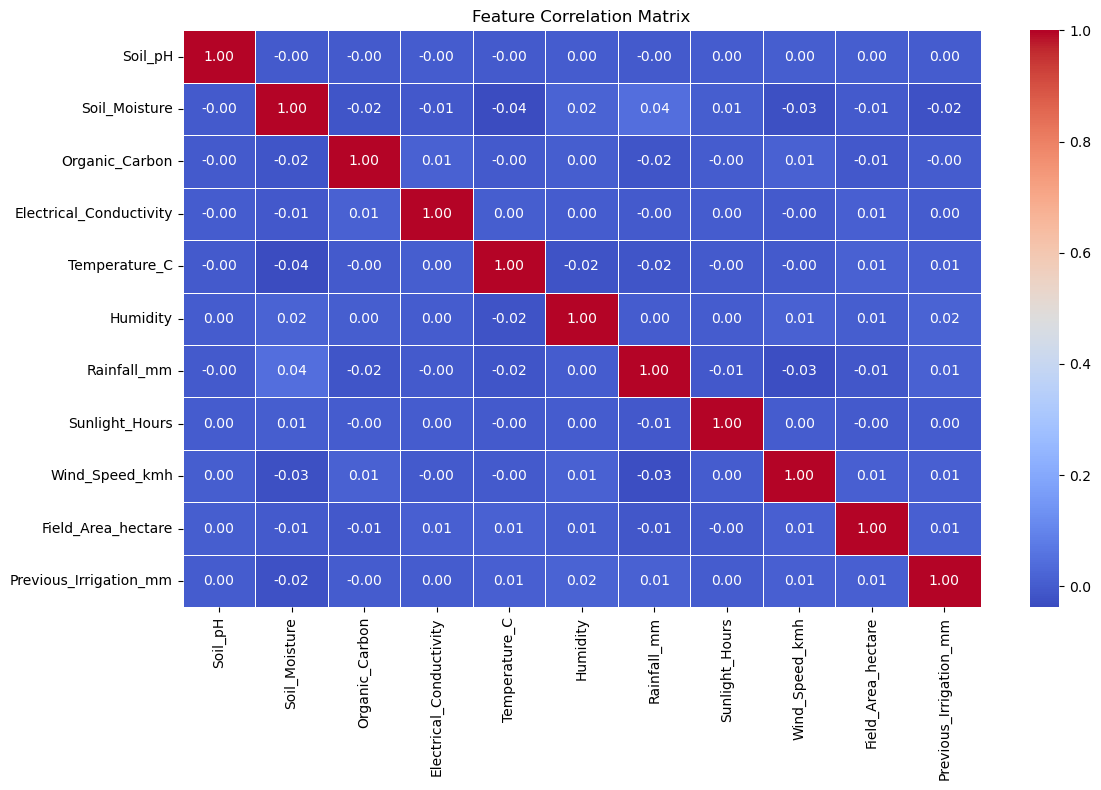


Shape after feature engineering → Train: (630000, 22)  Test: (270000, 21)
Encoded: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
Classes: ['High' 'Low' 'Medium'] → [0, 1, 2]
X: (630000, 20)  |  X_test: (270000, 20)
✅ Models defined!
XGBoost      │ CV Bal-Acc: 0.9616 ± 0.0003  [82.6s]
LightGBM     │ CV Bal-Acc: 0.9617 ± 0.0005  [56.2s]
CatBoost     │ CV Bal-Acc: 0.9606 ± 0.0007  [86.4s]

⏱  Total CV time: 225.2s
🏆 Best single model: LightGBM

Stacking CV Bal-Acc: 0.9578 ± 0.0007  [632.9s]

Fitting validation model...

✅ Validation Balanced Accuracy: 0.9620  (96.20%)
              precision    recall  f1-score   support

        High       0.97      0.91      0.94      4202
         Low       0.99      0.99      0.99     73983
      Medium       0.98      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99    

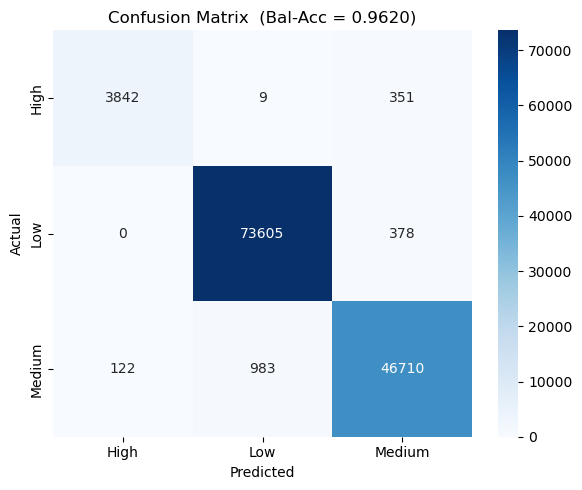

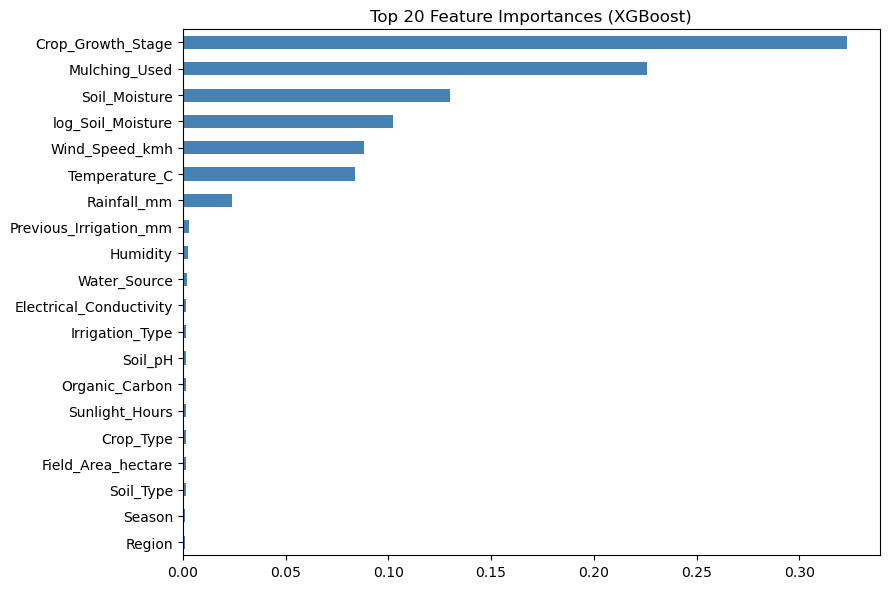


Training final stacking model on FULL data...
✅ Done in 429.5s
✅ submission.csv saved!
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
5  630005          Medium
6  630006             Low
7  630007          Medium
8  630008          Medium
9  630009             Low

Prediction counts:
Irrigation_Need
Low       159788
Medium    101810
High        8402
Name: count, dtype: int64


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')
 
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.base import clone
 
print(' All libraries imported!')
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
sub   = pd.read_csv('sample_submission.csv')
 
print(f'Train : {train.shape}  |  Test : {test.shape}')
print(train.head())
print('\n=== Data Types ===\n', train.dtypes)
print('\n=== Missing (Train) ===\n', train.isnull().sum())
print('\n=== Missing (Test)  ===\n', test.isnull().sum())
print('\n=== Target Distribution ===')
print(train['Irrigation_Need'].value_counts(normalize=True).round(3)) 
plt.figure(figsize=(7, 4))
train['Irrigation_Need'].value_counts().plot(
    kind='bar', color=['#2ecc71', '#3498db', '#e74c3c'])
plt.title('Target Class Distribution')
plt.xlabel('Irrigation Need'); plt.ylabel('Count')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
 
num_cols = [c for c in train.select_dtypes(include=[np.number]).columns if c != 'id']
plt.figure(figsize=(12, 8))
sns.heatmap(train[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout(); plt.show()
 
TARGET = 'Irrigation_Need'
ID_COL = 'id'
 
def engineer_features(df):
    df = df.copy()
    if {'Temperature', 'Humidity'}.issubset(df.columns):
        df['Temp_x_Humidity']     = df['Temperature'] * df['Humidity']
        df['Temp_minus_Humidity'] = df['Temperature'] - df['Humidity']
    if {'Soil_Moisture', 'Rainfall'}.issubset(df.columns):
        df['Moisture_Rain_Ratio'] = df['Soil_Moisture'] / (df['Rainfall'] + 1e-6)
    if {'Temperature', 'Wind_Speed'}.issubset(df.columns):
        df['ET_Proxy'] = df['Temperature'] * df['Wind_Speed']
    if {'Rainfall', 'Soil_Moisture'}.issubset(df.columns):
        df['Water_Deficit'] = df['Rainfall'] - df['Soil_Moisture']
    for col in ['Rainfall', 'Soil_Moisture', 'Wind_Speed']:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))
    return df
 
train = engineer_features(train)
test  = engineer_features(test)
print(f'\nShape after feature engineering → Train: {train.shape}  Test: {test.shape}')
cat_cols = [c for c in train.select_dtypes(include='object').columns if c != TARGET]
if cat_cols:
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    train[cat_cols] = oe.fit_transform(train[cat_cols])
    test[cat_cols]  = oe.transform(test[cat_cols])
    print(f'Encoded: {cat_cols}')
 
le = LabelEncoder()
y  = le.fit_transform(train[TARGET])
print(f'Classes: {le.classes_} → {list(range(len(le.classes_)))}')
 
X      = train.drop(columns=[ID_COL, TARGET], errors='ignore')
X_test = test.drop(columns=[ID_COL], errors='ignore')
print(f'X: {X.shape}  |  X_test: {X_test.shape}')
xgb_model = XGBClassifier(
    tree_method      = 'hist',      # ← FAST histogram algorithm
    n_estimators     = 300,         # was 800
    learning_rate    = 0.07,        # slightly higher → fewer trees needed
    max_depth        = 6,           # was 7; shallower = faster
    subsample        = 0.8,
    colsample_bytree = 0.8,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1
)
lgbm_model = LGBMClassifier(
    n_estimators     = 300,         # was 800
    learning_rate    = 0.07,
    max_depth        = 6,
    num_leaves       = 50,          # was 63
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1
)
cat_model = CatBoostClassifier(
    iterations    = 300,            # was 800
    learning_rate = 0.07,
    depth         = 6,              # was 7
    l2_leaf_reg   = 3,
    random_state  = 42,
    verbose       = 0,
    thread_count  = -1              # use all cores
)
 
print('✅ Models defined!')
 
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
 
results = {}
t0 = time.time()
for name, model in [('XGBoost', xgb_model),
                     ('LightGBM', lgbm_model),
                     ('CatBoost', cat_model)]:
    t = time.time()
    scores = cross_val_score(model, X, y, cv=cv,
                             scoring='balanced_accuracy', n_jobs=-1)
    results[name] = scores
    print(f'{name:12s} │ CV Bal-Acc: {scores.mean():.4f} ± {scores.std():.4f}'
          f'  [{time.time()-t:.1f}s]')
 
print(f'\n⏱  Total CV time: {time.time()-t0:.1f}s')
print(f' Best single model: {max(results, key=lambda k: results[k].mean())}')
stacking_clf = StackingClassifier(
    estimators=[
        ('xgb', XGBClassifier(
            tree_method='hist', n_estimators=300, learning_rate=0.07,
            max_depth=6, subsample=0.8, colsample_bytree=0.8,
            eval_metric='mlogloss', random_state=42, n_jobs=-1)),
        ('lgbm', LGBMClassifier(
            n_estimators=300, learning_rate=0.07, max_depth=6,
            num_leaves=50, subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbose=-1)),
        ('cat', CatBoostClassifier(
            iterations=300, learning_rate=0.07, depth=6,
            l2_leaf_reg=3, random_state=42, verbose=0, thread_count=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, C=1.0),
    cv=3,                           # was 5
    stack_method='predict_proba',
    passthrough=True,
    n_jobs=-1
)
 
t = time.time()
stacking_scores = cross_val_score(stacking_clf, X, y, cv=cv,
                                   scoring='balanced_accuracy', n_jobs=-1)
print(f'\nStacking CV Bal-Acc: {stacking_scores.mean():.4f} ± {stacking_scores.std():.4f}'
      f'  [{time.time()-t:.1f}s]')
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
 
val_model = clone(stacking_clf)
print('\nFitting validation model...')
val_model.fit(X_tr, y_tr)
 
y_val_pred = val_model.predict(X_val)
bal_acc    = balanced_accuracy_score(y_val, y_val_pred)
print(f'\n✅ Validation Balanced Accuracy: {bal_acc:.4f}  ({bal_acc*100:.2f}%)')
print(classification_report(y_val, y_val_pred, target_names=le.classes_))
 
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix  (Bal-Acc = {bal_acc:.4f})')
plt.tight_layout(); plt.show()
 
xgb_fi = XGBClassifier(
    tree_method='hist', n_estimators=300, learning_rate=0.07,
    max_depth=6, subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
xgb_fi.fit(X, y)
 
pd.Series(xgb_fi.feature_importances_, index=X.columns)\
  .sort_values(ascending=False).head(20)\
  .plot(kind='barh', figsize=(9, 6), color='steelblue')
plt.title('Top 20 Feature Importances (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
print('\nTraining final stacking model on FULL data...')
t = time.time()
stacking_clf.fit(X, y)
print(f'✅ Done in {time.time()-t:.1f}s')
 
test_preds = le.inverse_transform(stacking_clf.predict(X_test))
 
submission = sub.copy()
submission['Irrigation_Need'] = test_preds
submission.to_csv('submission.csv', index=False)
 
print(' submission.csv saved!')
print(submission.head(10))
print('\nPrediction counts:')
print(submission['Irrigation_Need'].value_counts())